In [33]:
1+1

2

# Figure 1 Reproduction

Independent reconstruction of selected panels from Figure 1
of "A number simplex in the human medial temporal lobe".

## Figure 1D — Arithmetic firing-rate tuning
Example neuron: YFU.hpc.43

In [34]:
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import csc_matrix

In [35]:
# Project paths
project_dir = Path("..")

raw_dir = project_dir / "data" / "raw"
figures_dir = project_dir / "figures"
tables_dir = project_dir / "tables"
results_dir = project_dir / "results"

# Make sure output folders exist
figures_dir.mkdir(exist_ok=True)
tables_dir.mkdir(exist_ok=True)
results_dir.mkdir(exist_ok=True)

print("Raw data:", raw_dir)
print("Figures:", figures_dir)
print("Tables:", tables_dir)
print("Results:", results_dir)

Raw data: ..\data\raw
Figures: ..\figures
Tables: ..\tables
Results: ..\results


In [36]:
subject = "YFU"

yfu_dir = raw_dir / subject / "arithmetic"

spike_path = yfu_dir / "spikes.mat"
behav_path = yfu_dir / "photoBehavEvents.csv"

print("Spike file:", spike_path)
print("Behavior file:", behav_path)

print("Spike exists:", spike_path.exists())
print("Behavior exists:", behav_path.exists())

Spike file: ..\data\raw\YFU\arithmetic\spikes.mat
Behavior file: ..\data\raw\YFU\arithmetic\photoBehavEvents.csv
Spike exists: True
Behavior exists: True


In [37]:
def decode_matlab_string(f, ref):
    obj = f[ref]
    values = obj[()].flatten()
    return "".join(chr(int(x)) for x in values)

In [38]:
with h5py.File(spike_path, "r") as f:

    spikes = f["spikes"]

    yfu_spike_matrix = csc_matrix(
        (
            spikes["data"][:],
            spikes["ir"][:],
            spikes["jc"][:]
        ),
        shape=(
            int(spikes.attrs["MATLAB_sparse"]),
            len(spikes["jc"]) - 1
        )
    )

    regions = f["regionsVect"]

    yfu_region_labels = [
        decode_matlab_string(f, ref)
        for ref in regions[0]
    ]

print("Spike matrix shape:", yfu_spike_matrix.shape)
print("Number of region labels:", len(yfu_region_labels))

Spike matrix shape: (78, 2273935)
Number of region labels: 78


In [39]:
yfu_behav = pd.read_csv(behav_path)

print("Behavior shape:", yfu_behav.shape)
print("\nColumns:")
print(yfu_behav.columns.tolist())

Behavior shape: (300, 22)

Columns:
['trial', 'tCue1', 'tCue2', 'tCue3', 'presentationEnd', 'tPress1', 'tPress2', 'tPress3', 'keyPress1', 'keyPress2', 'keyPress3', 'choiceEnd', 'timeFeedback', 'cue1', 'cue2', 'operation', 'operationFirst', 'correctAnsw', 'givenAnsw', 'correct', 'correctFb', 'toExclude']


In [40]:
unique_regions, counts = np.unique(
    yfu_region_labels,
    return_counts=True
)

for region, count in zip(unique_regions, counts):
    print(f"{region}: {count}")

acc: 16
amy: 23
hpc: 39


In [41]:
yfu_aligned = yfu_behav.copy()

yfu_aligned["operand1_time"] = np.where(
    yfu_aligned["operationFirst"] == 1,
    yfu_aligned["tCue2"],
    yfu_aligned["tCue1"]
)

yfu_aligned["operation_time"] = np.where(
    yfu_aligned["operationFirst"] == 1,
    yfu_aligned["tCue1"],
    yfu_aligned["tCue3"]
)

yfu_aligned["operand2_time"] = np.where(
    yfu_aligned["operationFirst"] == 1,
    yfu_aligned["tCue3"],
    yfu_aligned["tCue2"]
)

In [42]:
yfu_aligned[
    [
        "trial",
        "cue1",
        "operation",
        "cue2",
        "operationFirst",
        "tCue1",
        "tCue2",
        "tCue3",
        "operand1_time",
        "operation_time",
        "operand2_time"
    ]
].head(10)

,trial,cue1,operation,cue2,operationFirst,tCue1,tCue2,tCue3,operand1_time,operation_time,operand2_time
0,1,7,-,8,1,5910.833333,6660.833333,7410.800000,6660.833333,5910.833333,7410.800000
1,2,7,+,4,0,81376.233333,82126.233333,82876.233333,81376.233333,82876.233333,82126.233333
2,3,7,-,6,1,88876.133333,89626.100000,90376.100000,89626.100000,88876.133333,90376.100000
3,4,10,-,5,1,96092.666667,96842.633333,97592.633333,96842.633333,96092.666667,97592.633333
4,5,8,-,0,0,118708.933333,119458.933333,120208.933333,118708.933333,120208.933333,119458.933333
5,6,4,+,4,1,123892.200000,124642.166667,125392.166667,124642.166667,123892.200000,125392.166667
6,7,10,+,2,1,129525.433333,130275.433333,131025.400000,130275.433333,129525.433333,131025.400000
7,8,7,-,3,1,135025.333333,135775.333333,136525.300000,135775.333333,135025.333333,136525.300000
8,9,3,-,2,0,143491.866667,144241.833333,144991.833333,143491.866667,144991.833333,144241.833333
9,10,4,+,4,0,148841.766667,149575.100000,150341.733333,148841.766667,150341.733333,149575.100000


In [43]:
yfu_aligned[
    [
        "trial",
        "cue1",
        "operation",
        "cue2",
        "operationFirst",
        "tCue1",
        "tCue2",
        "tCue3",
        "operand1_time",
        "operation_time",
        "operand2_time"
    ]
].head(10)

,trial,cue1,operation,cue2,operationFirst,tCue1,tCue2,tCue3,operand1_time,operation_time,operand2_time
0,1,7,-,8,1,5910.833333,6660.833333,7410.800000,6660.833333,5910.833333,7410.800000
1,2,7,+,4,0,81376.233333,82126.233333,82876.233333,81376.233333,82876.233333,82126.233333
2,3,7,-,6,1,88876.133333,89626.100000,90376.100000,89626.100000,88876.133333,90376.100000
3,4,10,-,5,1,96092.666667,96842.633333,97592.633333,96842.633333,96092.666667,97592.633333
4,5,8,-,0,0,118708.933333,119458.933333,120208.933333,118708.933333,120208.933333,119458.933333
5,6,4,+,4,1,123892.200000,124642.166667,125392.166667,124642.166667,123892.200000,125392.166667
6,7,10,+,2,1,129525.433333,130275.433333,131025.400000,130275.433333,129525.433333,131025.400000
7,8,7,-,3,1,135025.333333,135775.333333,136525.300000,135775.333333,135025.333333,136525.300000
8,9,3,-,2,0,143491.866667,144241.833333,144991.833333,143491.866667,144991.833333,144241.833333
9,10,4,+,4,0,148841.766667,149575.100000,150341.733333,148841.766667,150341.733333,149575.100000


In [44]:
for i in range(5):

    row = yfu_aligned.iloc[i]

    print(
        f"Trial {int(row['trial'])}: "
        f"operationFirst={int(row['operationFirst'])}"
    )

    print(
        f"  Operand 1 = {row['cue1']} "
        f"at {row['operand1_time']:.2f} ms"
    )

    print(
        f"  Operation = {row['operation']} "
        f"at {row['operation_time']:.2f} ms"
    )

    print(
        f"  Operand 2 = {row['cue2']} "
        f"at {row['operand2_time']:.2f} ms"
    )

    print()

Trial 1: operationFirst=1
  Operand 1 = 7 at 6660.83 ms
  Operation = - at 5910.83 ms
  Operand 2 = 8 at 7410.80 ms

Trial 2: operationFirst=0
  Operand 1 = 7 at 81376.23 ms
  Operation = + at 82876.23 ms
  Operand 2 = 4 at 82126.23 ms

Trial 3: operationFirst=1
  Operand 1 = 7 at 89626.10 ms
  Operation = - at 88876.13 ms
  Operand 2 = 6 at 90376.10 ms

Trial 4: operationFirst=1
  Operand 1 = 10 at 96842.63 ms
  Operation = - at 96092.67 ms
  Operand 2 = 5 at 97592.63 ms

Trial 5: operationFirst=0
  Operand 1 = 8 at 118708.93 ms
  Operation = - at 120208.93 ms
  Operand 2 = 0 at 119458.93 ms



In [45]:
aligned_table_path = (
    tables_dir / "YFU_arithmetic_aligned_events.csv"
)

yfu_aligned.to_csv(
    aligned_table_path,
    index=False
)

print("Saved:", aligned_table_path)

Saved: ..\tables\YFU_arithmetic_aligned_events.csv


In [46]:
paper_unit = 43
neuron_id = paper_unit - 1

print("Paper unit:", paper_unit)
print("Python row:", neuron_id)
print("Region:", yfu_region_labels[neuron_id])

Paper unit: 43
Python row: 42
Region: hpc


In [47]:
yfu_hpc_rows = [
    i
    for i, region in enumerate(yfu_region_labels)
    if region == "hpc"
]

print("Number of YFU HPC neurons:", len(yfu_hpc_rows))
print("YFU HPC rows:")
print(yfu_hpc_rows)

Number of YFU HPC neurons: 39
YFU HPC rows:
[20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69]


In [48]:
neuron_id = 42

window_start_ms = 50
window_end_ms = 950
window_sec = (window_end_ms - window_start_ms) / 1000

presentation_rows = []

for trial_index, row in yfu_aligned.iterrows():

    # ==========================================
    # Operand 1
    # ==========================================

    number1 = row["cue1"]
    onset1 = row["operand1_time"]

    if (
        pd.notna(number1)
        and pd.notna(onset1)
        and 1 <= number1 <= 9
    ):

        start = int(round(onset1 + window_start_ms))
        end = int(round(onset1 + window_end_ms))

        spike_count = yfu_spike_matrix[
            neuron_id,
            start:end
        ].sum()

        firing_rate = float(spike_count) / window_sec

        presentation_rows.append({
            "trial_index": trial_index,
            "operand": 1,
            "number": int(number1),
            "onset_ms": onset1,
            "spike_count": int(spike_count),
            "firing_rate_hz": firing_rate
        })

    # ==========================================
    # Operand 2
    # ==========================================

    number2 = row["cue2"]
    onset2 = row["operand2_time"]

    if (
        pd.notna(number2)
        and pd.notna(onset2)
        and 1 <= number2 <= 9
    ):

        start = int(round(onset2 + window_start_ms))
        end = int(round(onset2 + window_end_ms))

        spike_count = yfu_spike_matrix[
            neuron_id,
            start:end
        ].sum()

        firing_rate = float(spike_count) / window_sec

        presentation_rows.append({
            "trial_index": trial_index,
            "operand": 2,
            "number": int(number2),
            "onset_ms": onset2,
            "spike_count": int(spike_count),
            "firing_rate_hz": firing_rate
        })

In [49]:
fig1d_presentations = pd.DataFrame(
    presentation_rows
)

print("Number of presentations:",
      len(fig1d_presentations))

fig1d_presentations.head()

Number of presentations: 494


,trial_index,operand,number,onset_ms,spike_count,firing_rate_hz
0,0,1,7,6660.833333,6,6.666667
1,0,2,8,7410.800000,7,7.777778
2,1,1,7,81376.233333,6,6.666667
3,1,2,4,82126.233333,7,7.777778
4,2,1,7,89626.100000,7,7.777778


In [50]:
fig1d_presentations[
    "number"
].value_counts().sort_index()

number
1    53
2    67
3    52
4    62
5    51
6    48
7    65
8    49
9    47
Name: count, dtype: int64

In [51]:
fig1d_summary = (
    fig1d_presentations
    .groupby("number")
    .agg(
        mean_firing_rate_hz=(
            "firing_rate_hz", "mean"
        ),
        sem_firing_rate_hz=(
            "firing_rate_hz", "sem"
        ),
        n_presentations=(
            "firing_rate_hz", "count"
        )
    )
    .reset_index()
)

fig1d_summary

,number,mean_firing_rate_hz,sem_firing_rate_hz,n_presentations
0,1,6.477987,0.379480,53
1,2,6.766169,0.330593,67
2,3,7.307692,0.416530,52
3,4,6.308244,0.360240,62
4,5,7.189542,0.400137,51
5,6,7.129630,0.392605,48
6,7,6.068376,0.309202,65
7,8,6.190476,0.369424,49
8,9,7.092199,0.356932,47


In [52]:
fig1d_presentations.to_csv(
    tables_dir /
    "figure1D_YFU_hpc43_presentations.csv",
    index=False
)

fig1d_summary.to_csv(
    tables_dir /
    "figure1D_YFU_hpc43_tuning_summary.csv",
    index=False
)

print("Figure 1D tables saved.")

Figure 1D tables saved.


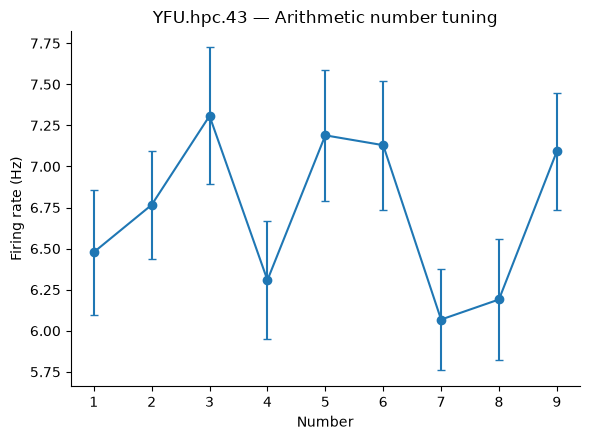

In [53]:
fig, ax = plt.subplots(figsize=(6, 4.5))

ax.errorbar(
    fig1d_summary["number"],
    fig1d_summary["mean_firing_rate_hz"],
    yerr=fig1d_summary["sem_firing_rate_hz"],
    marker="o",
    capsize=3,
    linewidth=1.5
)

ax.set_xlabel("Number")
ax.set_ylabel("Firing rate (Hz)")
ax.set_title("YFU.hpc.43 — Arithmetic number tuning")

ax.set_xticks(range(1, 10))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [54]:
figure_path = (
    figures_dir /
    "figure1D_YFU_hpc43_tuning.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

print("Saved:", figure_path)

Saved: ..\figures\figure1D_YFU_hpc43_tuning.png


# One Single function to reproduce the tuning curve plot for given neuron 

In [55]:
def make_number_tuning_figure(
    spike_matrix,
    behav_aligned,
    neuron_id,
    subject,
    region,
    paper_unit=None,
    figures_dir=None,
    tables_dir=None,
    window_start_ms=50,
    window_end_ms=950,
    save=True
):
    """
    Create a Figure-1D-style arithmetic number tuning curve.

    Uses:
      - Operand 1 + Operand 2 presentations
      - numbers 1–9 only
      - 50–950 ms after operand onset
      - mean firing rate ± SEM

    Returns
    -------
    presentations : DataFrame
        One row per eligible operand presentation.

    summary : DataFrame
        Mean firing rate, SEM, and number of presentations for numbers 1–9.

    fig, ax : matplotlib objects
    """

    window_sec = (
        window_end_ms - window_start_ms
    ) / 1000.0

    presentation_rows = []

    # ------------------------------------------
    # Extract Operand 1 + Operand 2 responses
    # ------------------------------------------
    for trial_index, row in behav_aligned.iterrows():

        for operand, number_col, time_col in [
            (1, "cue1", "operand1_time"),
            (2, "cue2", "operand2_time")
        ]:

            number = row[number_col]
            onset = row[time_col]

            if pd.isna(number) or pd.isna(onset):
                continue

            number = int(number)

            # Figures 1–3 use numbers 1–9
            if not (1 <= number <= 9):
                continue

            start = int(
                round(onset + window_start_ms)
            )

            end = int(
                round(onset + window_end_ms)
            )

            spike_count = spike_matrix[
                neuron_id,
                start:end
            ].sum()

            firing_rate = (
                float(spike_count) / window_sec
            )

            presentation_rows.append({
                "trial_index": trial_index,
                "operand": operand,
                "number": number,
                "onset_ms": onset,
                "spike_count": int(spike_count),
                "firing_rate_hz": firing_rate
            })

    presentations = pd.DataFrame(
        presentation_rows
    )

    # ------------------------------------------
    # Tuning summary
    # ------------------------------------------
    summary = (
        presentations
        .groupby("number")
        .agg(
            mean_firing_rate_hz=(
                "firing_rate_hz",
                "mean"
            ),
            sem_firing_rate_hz=(
                "firing_rate_hz",
                "sem"
            ),
            n_presentations=(
                "firing_rate_hz",
                "count"
            )
        )
        .reindex(range(1, 10))
        .reset_index()
    )

    # ------------------------------------------
    # Figure label
    # ------------------------------------------
    if paper_unit is not None:
        neuron_label = (
            f"{subject}.{region}.{paper_unit}"
        )
    else:
        neuron_label = (
            f"{subject} {region} "
            f"Python row {neuron_id}"
        )

    # ------------------------------------------
    # Plot
    # ------------------------------------------
    fig, ax = plt.subplots(
        figsize=(6, 4.5)
    )

    ax.errorbar(
        summary["number"],
        summary["mean_firing_rate_hz"],
        yerr=summary["sem_firing_rate_hz"],
        marker="o",
        capsize=3,
        linewidth=1.5
    )

    ax.set_xticks(range(1, 10))

    ax.set_xlabel("Number")
    ax.set_ylabel("Firing rate (Hz)")

    ax.set_title(
        f"{neuron_label} — Arithmetic number tuning"
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    fig.tight_layout()

    # ------------------------------------------
    # Save outputs
    # ------------------------------------------
    if save:

        if figures_dir is None or tables_dir is None:
            raise ValueError(
                "Provide figures_dir and tables_dir "
                "when save=True."
            )

        safe_label = neuron_label.replace(
            ".", "_"
        ).replace(
            " ", "_"
        )

        presentations.to_csv(
            tables_dir /
            f"{safe_label}_presentations.csv",
            index=False
        )

        summary.to_csv(
            tables_dir /
            f"{safe_label}_tuning_summary.csv",
            index=False
        )

        fig.savefig(
            figures_dir /
            f"{safe_label}_tuning.png",
            dpi=300,
            bbox_inches="tight"
        )

    return presentations, summary, fig, ax

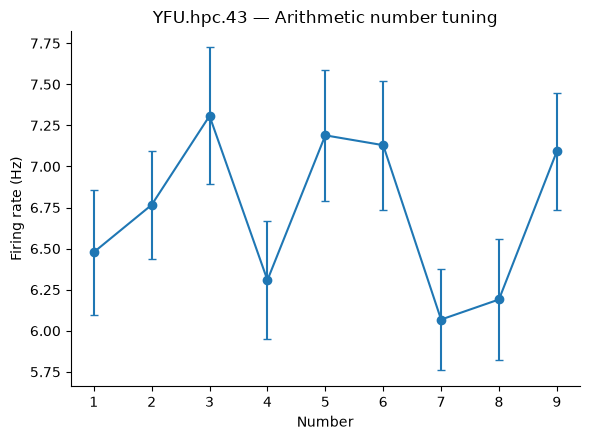

In [56]:
fig1d_presentations, fig1d_summary, fig, ax = (
    make_number_tuning_figure(
        spike_matrix=yfu_spike_matrix,
        behav_aligned=yfu_aligned,
        neuron_id=42,
        subject="YFU",
        region="hpc",
        paper_unit=43,
        figures_dir=figures_dir,
        tables_dir=tables_dir
    )
)

plt.show()

In [57]:
figure1I_units = [
    ("YFS", "amy", 27),
    ("YFS", "hpc", 38),
    ("YFT", "hpc", 50),
    ("YFT", "ent", 77),
    ("YFU", "amy", 2),
    ("YFU", "hpc", 24),
]


In [58]:
paper_unit = 24
neuron_id = paper_unit - 1

print("Paper unit:", paper_unit)
print("Python row:", neuron_id)
print("Region:", yfu_region_labels[neuron_id])

Paper unit: 24
Python row: 23
Region: hpc


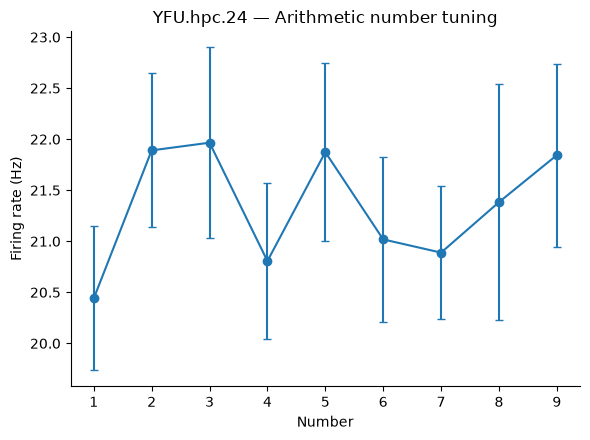

In [59]:
pres_hpc24, summary_hpc24, fig_hpc24, ax_hpc24 = (
    make_number_tuning_figure(
        spike_matrix=yfu_spike_matrix,
        behav_aligned=yfu_aligned,
        neuron_id=23,
        subject="YFU",
        region="hpc",
        paper_unit=24,
        figures_dir=figures_dir,
        tables_dir=tables_dir
    )
)

plt.show()

In [60]:
paper_unit = 2
neuron_id = paper_unit - 1

print("Paper unit:", paper_unit)
print("Python row:", neuron_id)
print("Region:", yfu_region_labels[neuron_id])

Paper unit: 2
Python row: 1
Region: amy


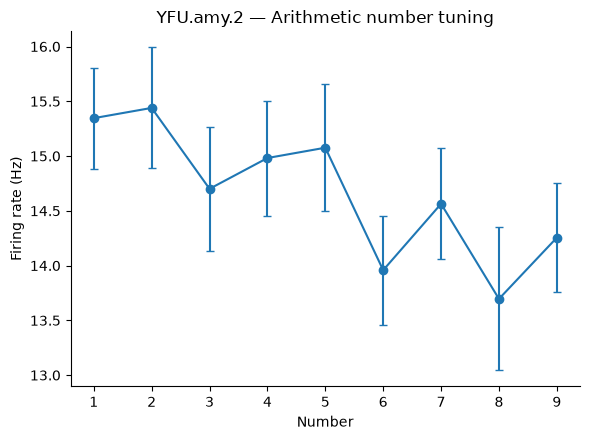

In [61]:
pres_amy02, summary_amy02, fig_amy02, ax_amy02 = (
    make_number_tuning_figure(
        spike_matrix=yfu_spike_matrix,
        behav_aligned=yfu_aligned,
        neuron_id=neuron_id,
        subject="YFU",
        region="amy",
        paper_unit=paper_unit,
        figures_dir=figures_dir,
        tables_dir=tables_dir
    )
)

plt.show()

In [62]:
subject = "YFT"

yft_dir = raw_dir / subject / "arithmetic"

spike_path_yft = yft_dir / "spikes.mat"
behav_path_yft = yft_dir / "photoBehavEvents.csv"

with h5py.File(spike_path_yft, "r") as f:

    spikes = f["spikes"]

    yft_spike_matrix = csc_matrix(
        (
            spikes["data"][:],
            spikes["ir"][:],
            spikes["jc"][:]
        ),
        shape=(
            int(spikes.attrs["MATLAB_sparse"]),
            len(spikes["jc"]) - 1
        )
    )

    regions = f["regionsVect"]

    yft_region_labels = [
        decode_matlab_string(f, ref)
        for ref in regions[0]
    ]

yft_behav = pd.read_csv(behav_path_yft)

print("Spike matrix:", yft_spike_matrix.shape)
print("Behavior:", yft_behav.shape)
print("Regions:", len(yft_region_labels))

Spike matrix: (89, 3167222)
Behavior: (300, 22)
Regions: 89


In [63]:
yft_aligned = yft_behav.copy()

yft_aligned["operand1_time"] = np.where(
    yft_aligned["operationFirst"] == 1,
    yft_aligned["tCue2"],
    yft_aligned["tCue1"]
)

yft_aligned["operation_time"] = np.where(
    yft_aligned["operationFirst"] == 1,
    yft_aligned["tCue1"],
    yft_aligned["tCue3"]
)

yft_aligned["operand2_time"] = np.where(
    yft_aligned["operationFirst"] == 1,
    yft_aligned["tCue3"],
    yft_aligned["tCue2"]
)

In [64]:
paper_unit = 50
neuron_id = paper_unit - 1

print("Paper unit:", paper_unit)
print("Python row:", neuron_id)
print("Region:", yft_region_labels[neuron_id])

Paper unit: 50
Python row: 49
Region: hpc


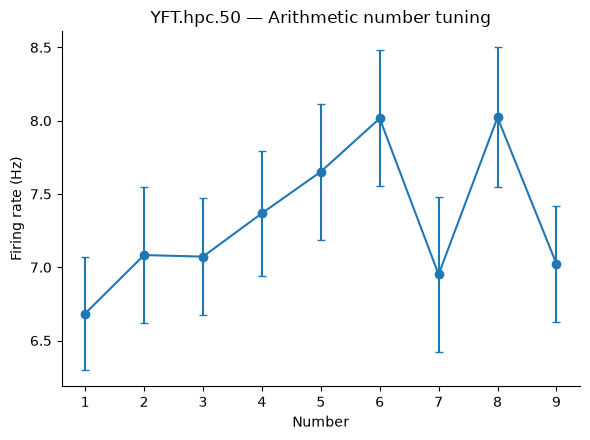

In [65]:
pres_yft_hpc50, summary_yft_hpc50, fig_yft_hpc50, ax_yft_hpc50 = (
    make_number_tuning_figure(
        spike_matrix=yft_spike_matrix,
        behav_aligned=yft_aligned,
        neuron_id=neuron_id,
        subject="YFT",
        region="hpc",
        paper_unit=paper_unit,
        figures_dir=figures_dir,
        tables_dir=tables_dir
    )
)

plt.show()

---

# next Figures E, F

E = spike raster from the same neuron as D, grouped by number and aligned to stimulus onset.
F = smoothed firing-rate traces using a Gaussian kernel with σ=150 ms, shown as mean ± SEM for numbers 1–9.

In [66]:
raster_rows = []

raster_start_ms = 0
raster_end_ms = 1000

for _, row in fig1d_presentations.iterrows():

    onset = row["onset_ms"]
    number = int(row["number"])

    start = int(round(onset + raster_start_ms))
    end = int(round(onset + raster_end_ms))

    spike_window = yfu_spike_matrix[
        42,
        start:end
    ].toarray().ravel()

    spike_positions = np.where(
        spike_window > 0
    )[0]

    # preserve repeated spikes if a bin contains >1
    for pos in spike_positions:

        count = int(spike_window[pos])

        for _ in range(count):

            raster_rows.append({
                "number": number,
                "trial_index": int(row["trial_index"]),
                "operand": int(row["operand"]),
                "spike_time_s": pos / 1000.0
            })

In [67]:
fig1e_raster = pd.DataFrame(raster_rows)

print(fig1e_raster.shape)
fig1e_raster.head()

(3311, 4)


,number,trial_index,operand,spike_time_s
0,7,0,1,0.020
1,7,0,1,0.133
2,7,0,1,0.266
3,7,0,1,0.839
4,7,0,1,0.849


this neuron produced 3,311 spikes during the 0–1 s windows.

0–1 s windows.

In [68]:
fig1e_raster

,number,trial_index,operand,spike_time_s
0,7,0,1,0.020
1,7,0,1,0.133
2,7,0,1,0.266
3,7,0,1,0.839
4,7,0,1,0.849
...,...,...,...,...
3306,2,298,2,0.114
3307,2,298,2,0.154
3308,2,298,2,0.217
3309,2,298,2,0.629


In [69]:
fig1e_raster.to_csv(
    tables_dir / "figure1E_YFU_hpc43_raster_spikes.csv",
    index=False
)

print("Raster table saved.")

Raster table saved.


In [70]:
presentation_order = (
    fig1d_presentations[
        ["trial_index", "operand", "number"]
    ]
    .drop_duplicates()
    .sort_values(
        ["number", "trial_index", "operand"]
    )
    .reset_index(drop=True)
)

presentation_order["raster_row"] = np.arange(
    len(presentation_order)
)

presentation_order.head()

,trial_index,operand,number,raster_row
0,18,1,1,0
1,33,2,1,1
2,48,2,1,2
3,56,2,1,3
4,60,1,1,4


In [71]:
fig1e_plot_data = fig1e_raster.merge(
    presentation_order,
    on=["trial_index", "operand", "number"],
    how="left"
)

fig1e_plot_data.head()

,number,trial_index,operand,spike_time_s,raster_row
0,7,0,1,0.020,333
1,7,0,1,0.133,333
2,7,0,1,0.266,333
3,7,0,1,0.839,333
4,7,0,1,0.849,333


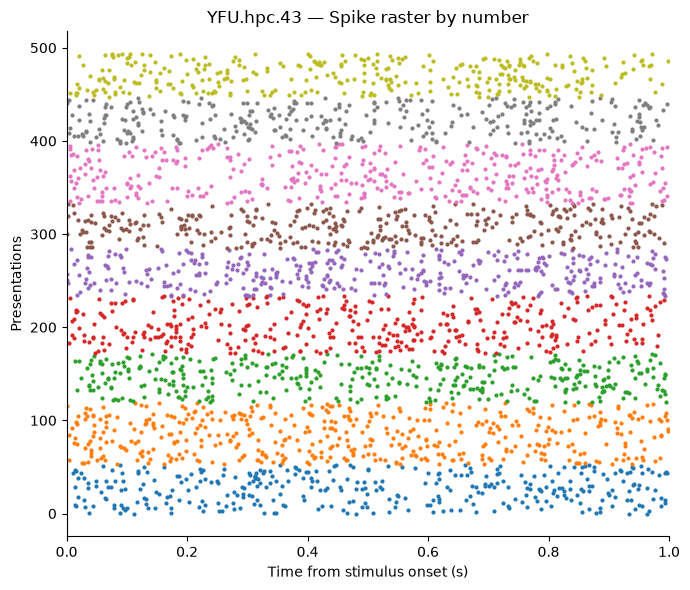

In [72]:
fig, ax = plt.subplots(figsize=(7, 6))

for number in range(1, 10):

    subset = fig1e_plot_data[
        fig1e_plot_data["number"] == number
    ]

    ax.scatter(
        subset["spike_time_s"],
        subset["raster_row"],
        s=4,
        label=str(number)
    )

ax.set_xlim(0, 1)

ax.set_xlabel("Time from stimulus onset (s)")
ax.set_ylabel("Presentations")

ax.set_title(
    "YFU.hpc.43 — Spike raster by number"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

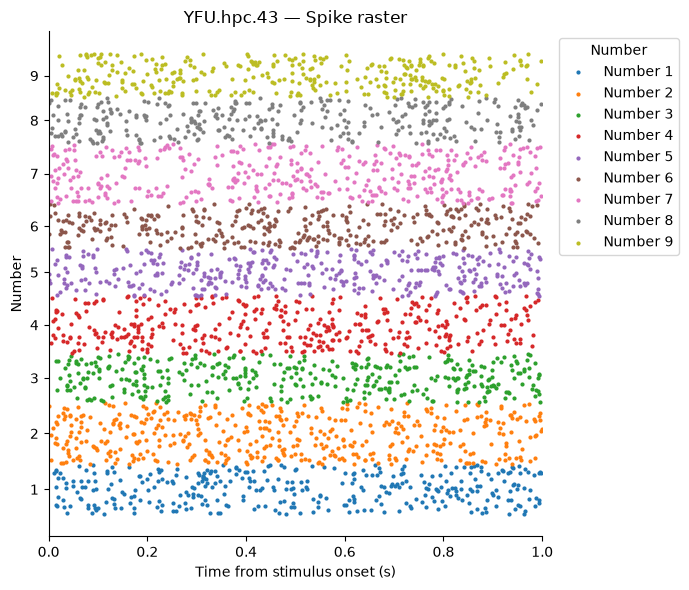

In [73]:
fig, ax = plt.subplots(figsize=(7, 6))

# Plot each number separately
for number in range(1, 10):

    subset = fig1e_plot_data[
        fig1e_plot_data["number"] == number
    ]

    ax.scatter(
        subset["spike_time_s"],
        subset["raster_row"],
        s=4,
        label=f"Number {number}"
    )

# -----------------------------------
# Find center of each number block
# -----------------------------------
number_centers = (
    presentation_order
    .groupby("number")["raster_row"]
    .mean()
)

ax.set_yticks(number_centers.values)
ax.set_yticklabels(
    [str(n) for n in number_centers.index]
)

ax.set_xlim(0, 1)

ax.set_xlabel("Time from stimulus onset (s)")
ax.set_ylabel("Number")
ax.set_title("YFU.hpc.43 — Spike raster")

# Legend: tells which color = which number
ax.legend(
    title="Number",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

fig.savefig(
    figures_dir /
    "figure1E_YFU_hpc43_raster_labeled.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Every single dot means:

YFU.hpc.43 fired one spike
Eg : ​a dot at

x=0.4

means the neuron fired 400 ms after the number appeared.



Each horizontal level( y axis colors) corresponds to a different presentation of a numbe

Nine colored blocks for each numbers

This is actually the spike train , given that number at time t = 0 , number of spikes happened after that till 1 s = 1000 ms

# Convolve the spike train , using Gaussian kernel   Figure 1 F


In [74]:
fig1e_plot_data.to_csv(
    tables_dir /
    "figure1E_YFU_hpc43_raster_plot_data.csv",
    index=False
)

fig.savefig(
    figures_dir /
    "figure1E_YFU_hpc43_raster.png",
    dpi=300,
    bbox_inches="tight"
)

print("Figure 1E saved.")

Figure 1E saved.


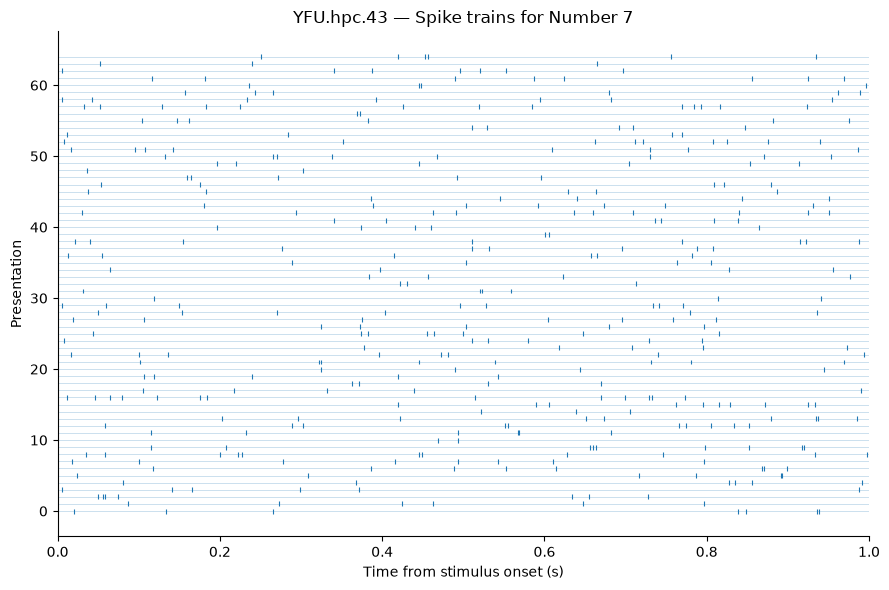

In [75]:
number = 7

number_data = fig1e_raster[
    fig1e_raster["number"] == number
]

presentations = (
    fig1d_presentations[
        fig1d_presentations["number"] == number
    ][["trial_index", "operand"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(9, 6))

for row_id, p in presentations.iterrows():

    # Get spike times for this presentation
    spike_times = number_data[
        (number_data["trial_index"] == p["trial_index"]) &
        (number_data["operand"] == p["operand"])
    ]["spike_time_s"].values

    # Horizontal baseline
    ax.hlines(
        y=row_id,
        xmin=0,
        xmax=1,
        linewidth=0.4,
        alpha=0.4
    )

    # Vertical spike ticks
    ax.vlines(
        spike_times,
        ymin=row_id - 0.35,
        ymax=row_id + 0.35,
        linewidth=0.8
    )

ax.set_xlim(0, 1)

ax.set_xlabel("Time from stimulus onset (s)")
ax.set_ylabel("Presentation")

ax.set_title(
    "YFU.hpc.43 — Spike trains for Number 7"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

##  Convolve the spike train , using Gaussian kernel   Figure 1 F

In [76]:
from scipy.ndimage import gaussian_filter1d

sigma_ms = 150

# because our time axis is sampled every 1 ms:
sigma_samples = sigma_ms

In [77]:
example = fig1d_presentations.iloc[0]

onset = example["onset_ms"]
number = int(example["number"])

start = int(round(onset))
end = int(round(onset + 1000))

spike_train = (
    yfu_spike_matrix[42, start:end]
    .toarray()
    .ravel()
    .astype(float)
)

In [78]:
smoothed_rate = gaussian_filter1d(
    spike_train,
    sigma=sigma_samples,
    mode="constant"
)

# Convert spikes/ms to spikes/s = Hz
smoothed_rate_hz = smoothed_rate * 1000

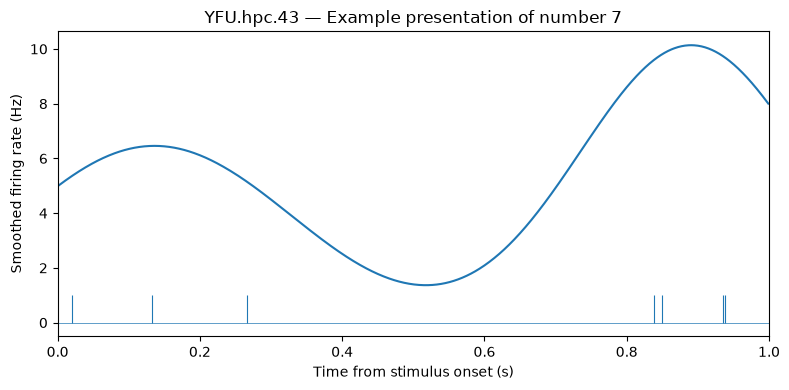

In [79]:
time_s = np.arange(len(spike_train)) / 1000

fig, ax = plt.subplots(figsize=(8, 4))

# horizontal baseline
ax.hlines(
    0,
    xmin=0,
    xmax=1,
    linewidth=0.5
)

# spike ticks
spike_times = np.where(spike_train > 0)[0] / 1000

ax.vlines(
    spike_times,
    ymin=0,
    ymax=1,
    linewidth=0.8
)

# smoothed firing-rate trace
ax.plot(
    time_s,
    smoothed_rate_hz
)

ax.set_xlim(0, 1)

ax.set_xlabel("Time from stimulus onset (s)")
ax.set_ylabel("Smoothed firing rate (Hz)")

ax.set_title(
    f"YFU.hpc.43 — Example presentation of number {number}"
)

plt.tight_layout()
plt.show()

# Full plot 

In [80]:
from scipy.ndimage import gaussian_filter1d

sigma_ms = 150

# Plot interval
plot_start_ms = 0
plot_end_ms = 1000

# Extra padding for Gaussian smoothing
padding_ms = 450   # 3 sigma

temporal_rows = []

for presentation_id, row in fig1d_presentations.iterrows():

    onset = row["onset_ms"]
    number = int(row["number"])

    # Extract a wider interval first
    start = int(round(
        onset + plot_start_ms - padding_ms
    ))

    end = int(round(
        onset + plot_end_ms + padding_ms
    ))

    spike_train = (
        yfu_spike_matrix[
            42,
            start:end
        ]
        .toarray()
        .ravel()
        .astype(float)
    )

    # Gaussian smoothing
    smooth_rate = gaussian_filter1d(
        spike_train,
        sigma=sigma_ms,
        mode="constant"
    )

    # spikes/ms -> spikes/s = Hz
    smooth_rate_hz = smooth_rate * 1000

    # Remove padding after smoothing
    smooth_rate_hz = smooth_rate_hz[
        padding_ms:
        padding_ms + (plot_end_ms - plot_start_ms)
    ]

    for t_ms, rate in enumerate(smooth_rate_hz):

        temporal_rows.append({
            "presentation_id": presentation_id,
            "trial_index": row["trial_index"],
            "operand": row["operand"],
            "number": number,
            "time_s": t_ms / 1000,
            "firing_rate_hz": rate
        })

In [81]:
fig1f_temporal = pd.DataFrame(
    temporal_rows
)

print(fig1f_temporal.shape)
fig1f_temporal.head()

(494000, 6)


,presentation_id,trial_index,operand,number,time_s,firing_rate_hz
0,0,0.0,1.0,7,0.000,6.693481
1,0,0.0,1.0,7,0.001,6.702203
2,0,0.0,1.0,7,0.002,6.710837
3,0,0.0,1.0,7,0.003,6.719381
4,0,0.0,1.0,7,0.004,6.727836


In [82]:
fig1f_summary = (
    fig1f_temporal
    .groupby(
        ["number", "time_s"]
    )
    .agg(
        mean_rate_hz=(
            "firing_rate_hz",
            "mean"
        ),
        sem_rate_hz=(
            "firing_rate_hz",
            "sem"
        ),
        n_presentations=(
            "firing_rate_hz",
            "count"
        )
    )
    .reset_index()
)

fig1f_summary.head()

,number,time_s,mean_rate_hz,sem_rate_hz,n_presentations
0,1,0.000,6.690746,0.546338,53
1,1,0.001,6.692126,0.546562,53
2,1,0.002,6.693480,0.546783,53
3,1,0.003,6.694825,0.547005,53
4,1,0.004,6.696128,0.547219,53


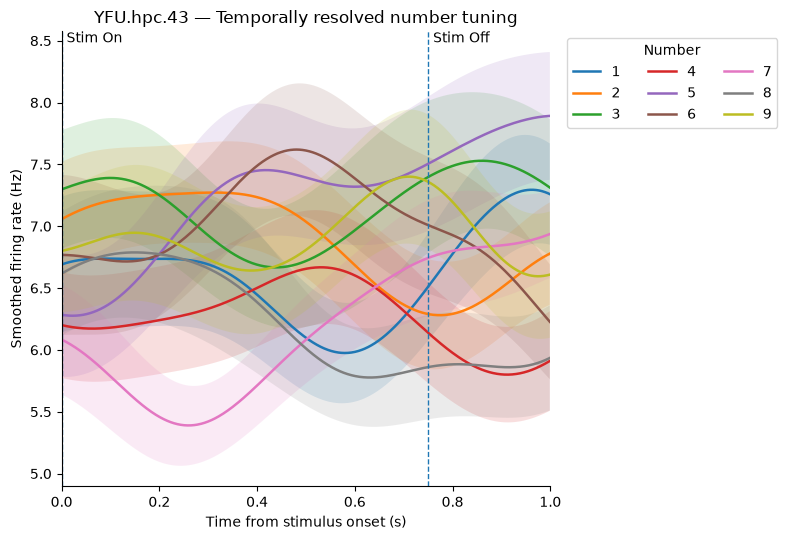

In [83]:
fig, ax = plt.subplots(
    figsize=(8, 5.5)
)

for number in range(1, 10):

    subset = fig1f_summary[
        fig1f_summary["number"] == number
    ]

    x = subset["time_s"].to_numpy()
    mean = subset["mean_rate_hz"].to_numpy()
    sem = subset["sem_rate_hz"].to_numpy()

    # Mean temporal firing rate
    line, = ax.plot(
        x,
        mean,
        linewidth=1.8,
        label=str(number)
    )

    # SEM band
    ax.fill_between(
        x,
        mean - sem,
        mean + sem,
        alpha=0.15
    )

# Stimulus timing
ax.axvline(
    0,
    linestyle="--",
    linewidth=1
)

ax.axvline(
    0.75,
    linestyle="--",
    linewidth=1
)

ax.text(
    0.01,
    ax.get_ylim()[1],
    "Stim On",
    va="top"
)

ax.text(
    0.76,
    ax.get_ylim()[1],
    "Stim Off",
    va="top"
)

ax.set_xlim(0, 1)

ax.set_xlabel(
    "Time from stimulus onset (s)"
)

ax.set_ylabel(
    "Smoothed firing rate (Hz)"
)

ax.set_title(
    "YFU.hpc.43 — Temporally resolved number tuning"
)

ax.legend(
    title="Number",
    ncol=3,
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.show()

Each color corresponds to one displayed number, 1,…,9. When number 1 was presented repeatedly, how did the average firing rate of YFU.hpc.43 change over time after number onset? For example, if the green curve is around

7.5 Hz

at t=0.85, it means that around 850 ms after presentations of that number, this neuron had an estimated average firing rate of roughly 7.5 spikes/

the shaded regions

Those are the SEM bands:

mean±SEM
	​


They represent uncertainty/variability in our estimate of the mean temporal firing-rate trajectory across presentations.

In [84]:
fig1f_summary.to_csv(
    tables_dir /
    "figure1F_YFU_hpc43_temporal_tuning_summary.csv",
    index=False
)

fig.savefig(
    figures_dir /
    "figure1F_YFU_hpc43_temporal_tuning.png",
    dpi=300,
    bbox_inches="tight"
)

print("Figure 1F and summary table saved.")

Figure 1F and summary table saved.


## Gaussin COnvolved spike trains ABOVE 

---

## LDA analysis

# Figure 1 G, LDA classifiers and bins

Making using of the best bin size and gamm that found using grid search for hpc 43 YFU

In [88]:
bin_ms = 150
n_bins = 900 // bin_ms

X_rows = []
y_labels = []
meta_rows = []

for _, row in fig1d_presentations.iterrows():

    onset = row["onset_ms"]
    number = int(row["number"])

    start = int(round(onset + 50))
    end = int(round(onset + 950))

    spike_window = (
        yfu_spike_matrix[
            42,
            start:end
        ]
        .toarray()
        .ravel()
    )

    binned_counts = spike_window.reshape(
        n_bins,
        bin_ms
    ).sum(axis=1)

    X_rows.append(binned_counts)
    y_labels.append(number)

    meta_rows.append({
        "trial_index": row["trial_index"],
        "operand": row["operand"],
        "number": number
    })

X_g = np.vstack(X_rows)
y_g = np.array(y_labels)

print("X shape:", X_g.shape)
print("y shape:", y_g.shape)

print("\nFirst temporal vector:")
print(X_g[0])

print("Label:")
print(y_g[0])

X shape: (494, 6)
y shape: (494,)

First temporal vector:
[1 1 0 0 0 4]
Label:
7


In [87]:
X_rows

[array([1, 1, 0, 0, 0, 4], dtype=uint64),
 array([4, 0, 1, 0, 2, 0], dtype=uint64),
 array([1, 1, 2, 1, 1, 0], dtype=uint64),
 array([0, 3, 1, 1, 2, 0], dtype=uint64),
 array([4, 0, 0, 1, 2, 0], dtype=uint64),
 array([0, 2, 3, 0, 0, 1], dtype=uint64),
 array([1, 1, 0, 0, 2, 0], dtype=uint64),
 array([0, 1, 0, 1, 1, 1], dtype=uint64),
 array([1, 0, 0, 1, 0, 1], dtype=uint64),
 array([1, 2, 4, 2, 0, 0], dtype=uint64),
 array([2, 1, 1, 2, 1, 2], dtype=uint64),
 array([2, 1, 1, 0, 0, 0], dtype=uint64),
 array([0, 1, 1, 1, 0, 3], dtype=uint64),
 array([1, 2, 2, 1, 3, 1], dtype=uint64),
 array([1, 0, 1, 1, 1, 4], dtype=uint64),
 array([1, 0, 2, 2, 2, 1], dtype=uint64),
 array([2, 1, 0, 1, 0, 0], dtype=uint64),
 array([0, 1, 3, 0, 0, 2], dtype=uint64),
 array([2, 0, 0, 2, 1, 0], dtype=uint64),
 array([1, 0, 1, 0, 0, 3], dtype=uint64),
 array([3, 1, 0, 1, 0, 0], dtype=uint64),
 array([0, 1, 0, 0, 2, 2], dtype=uint64),
 array([1, 0, 2, 2, 0, 3], dtype=uint64),
 array([3, 0, 1, 1, 1, 2], dtype=u

In [89]:
fig1g_features = pd.DataFrame(
    X_g,
    columns=[
        "bin1",
        "bin2",
        "bin3",
        "bin4",
        "bin5",
        "bin6"
    ]
)

fig1g_meta = pd.DataFrame(meta_rows)

fig1g_table = pd.concat(
    [fig1g_meta, fig1g_features],
    axis=1
)

fig1g_table.to_csv(
    tables_dir /
    "figure1G_YFU_hpc43_temporal_features.csv",
    index=False
)

fig1g_table.head()

,trial_index,operand,number,bin1,bin2,bin3,bin4,bin5,bin6
0,0.0,1.0,7,1,1,0,0,0,4
1,0.0,2.0,8,4,0,1,0,2,0
2,1.0,1.0,7,1,1,2,1,1,0
3,1.0,2.0,4,0,3,1,1,2,0
4,2.0,1.0,7,4,0,0,1,2,0


In [90]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis()

X_lda = lda.fit_transform(X_g, y_g)

print("Input X:", X_g.shape)
print("LDA projection:", X_lda.shape)
print("Classes:", lda.classes_)
print("Coefficient shape:", lda.coef_.shape)

Input X: (494, 6)
LDA projection: (494, 6)
Classes: [1 2 3 4 5 6 7 8 9]
Coefficient shape: (9, 6)


LDA can produce at most

min(6,9−1)=
6

discriminant dimensions.

In [91]:
lda1_weights = lda.scalings_[:, 0]
lda2_weights = lda.scalings_[:, 1]

print("LDA1:")
print(lda1_weights)

print("\nLDA2:")
print(lda2_weights)

LDA1:
[ 0.05928521 -0.12126077 -0.18535751 -0.50187432  0.51660026 -0.69132939]

LDA2:
[-0.12612907 -0.89310921  0.14251826  0.42353864 -0.2176158  -0.3521332 ]


In [92]:
bin_centers_ms = (
    50
    + np.arange(6) * 150
    + 75
)

fig1g_weights = pd.DataFrame({
    "bin": np.arange(1, 7),
    "time_ms": bin_centers_ms,
    "LDA1": lda1_weights,
    "LDA2": lda2_weights
})

fig1g_weights

,bin,time_ms,LDA1,LDA2
0,1,125,0.059285,-0.126129
1,2,275,-0.121261,-0.893109
2,3,425,-0.185358,0.142518
3,4,575,-0.501874,0.423539
4,5,725,0.516600,-0.217616
5,6,875,-0.691329,-0.352133


In [93]:
fig1g_weights.to_csv(
    tables_dir /
    "figure1G_YFU_hpc43_LDA_weights.csv",
    index=False
)

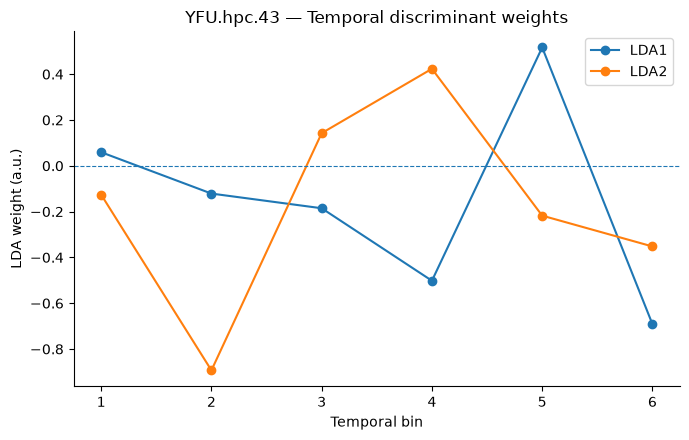

In [94]:
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(
    fig1g_weights["time_ms"] / 1000,
    fig1g_weights["LDA1"],
    marker="o",
    label="LDA1"
)

ax.plot(
    fig1g_weights["time_ms"] / 1000,
    fig1g_weights["LDA2"],
    marker="o",
    label="LDA2"
)

ax.axhline(
    0,
    linewidth=0.8,
    linestyle="--"
)

ax.set_xticks(
    fig1g_weights["time_ms"] / 1000
)

ax.set_xticklabels(
    fig1g_weights["bin"]
)

ax.set_xlabel("Temporal bin")
ax.set_ylabel("LDA weight (a.u.)")

ax.set_title(
    "YFU.hpc.43 — Temporal discriminant weights"
)

ax.legend()

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

fig.savefig(
    figures_dir /
    "figure1G_YFU_hpc43_LDA_weights.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The sign od discriminant direction is arbitrary , in paper it was multiplied by a negative sign 

Do it for all LDA components ,not just two , here it is 6 components 

also note best bin size is 6 

In [95]:
# All available LDA component weights
all_lda_weights = lda.scalings_

print("Shape:", all_lda_weights.shape)

Shape: (6, 6)


In [96]:
fig1g_all_weights = pd.DataFrame({
    "bin": np.arange(1, 7),
    "time_ms": bin_centers_ms
})

for component in range(all_lda_weights.shape[1]):
    fig1g_all_weights[
        f"LDA{component + 1}"
    ] = all_lda_weights[:, component]

fig1g_all_weights

,bin,time_ms,LDA1,LDA2,LDA3,LDA4,LDA5,LDA6
0,1,125,0.059285,-0.126129,-0.677911,-0.349532,-0.527969,0.231476
1,2,275,-0.121261,-0.893109,0.337475,-0.403351,-0.089506,-0.148936
2,3,425,-0.185358,0.142518,0.248648,-0.260827,0.214930,0.918168
3,4,575,-0.501874,0.423539,-0.163303,-0.685029,0.349630,-0.351448
4,5,725,0.516600,-0.217616,-0.389990,-0.078980,0.658634,0.110651
5,6,875,-0.691329,-0.352133,-0.431029,0.476033,0.189545,0.051195


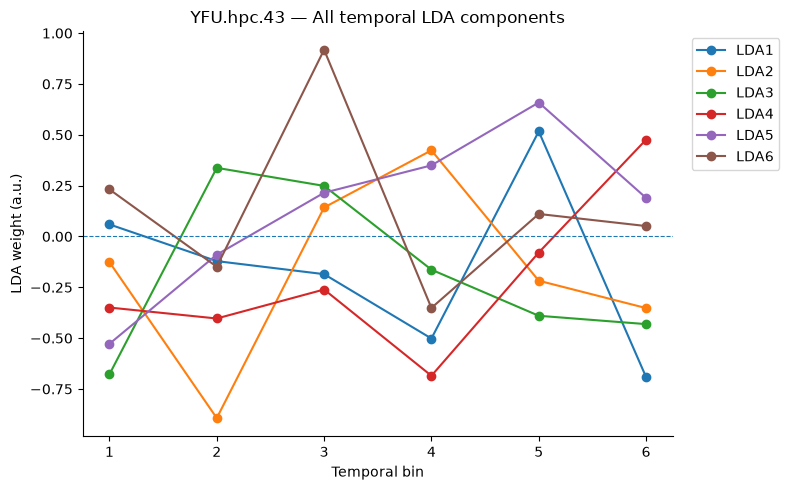

In [97]:
fig, ax = plt.subplots(figsize=(8, 5))

for component in range(1, 7):

    ax.plot(
        fig1g_all_weights["bin"],
        fig1g_all_weights[f"LDA{component}"],
        marker="o",
        linewidth=1.5,
        label=f"LDA{component}"
    )

ax.axhline(
    0,
    linestyle="--",
    linewidth=0.8
)

ax.set_xticks(range(1, 7))

ax.set_xlabel("Temporal bin")
ax.set_ylabel("LDA weight (a.u.)")

ax.set_title(
    "YFU.hpc.43 — All temporal LDA components"
)

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

fig.savefig(
    figures_dir /
    "figure1G_YFU_hpc43_all_LDA_components.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

LDA find the boundary :  z1​=w11​x1​+w12​x2​+⋯+w16​x6​​

In [98]:
fig1g_all_weights.to_csv(
    tables_dir /
    "figure1G_YFU_hpc43_all_LDA_components.csv",
    index=False
)

NOt easy to use all 6 direction components , so let suse only two components and projections 

In [99]:
X_lda = lda.fit_transform(X_g, y_g)

In [100]:
fig1h_projection = pd.DataFrame({
    "trial_index": fig1g_meta["trial_index"],
    "operand": fig1g_meta["operand"],
    "number": y_g,
    "TC1": X_lda[:, 0],
    "TC2": X_lda[:, 1]
})

fig1h_projection.head()

,trial_index,operand,number,TC1,TC2
0,0.0,1.0,7,-1.936622,-1.420253
1,0.0,2.0,8,1.975655,0.210289
2,1.0,1.0,7,0.472706,0.479240
3,1.0,2.0,4,0.872857,-1.540984
4,2.0,1.0,7,1.659138,0.491309


In [101]:
fig1h_projection.to_csv(
    tables_dir /
    "figure1H_YFU_hpc43_TC_projection.csv",
    index=False
)

In [102]:
fig1h_centroids = (
    fig1h_projection
    .groupby("number")[["TC1", "TC2"]]
    .mean()
)

fig1h_centroids

,TC1,TC2
number,,
1,-0.026349,-0.319680
2,-0.018953,0.028632
3,-0.282085,-0.067765
4,-0.008266,0.232452
5,-0.114334,-0.207423
6,-0.444294,0.104853
7,0.169354,0.249742
8,0.264480,0.008381
9,0.447594,-0.148125


In [103]:
fig1h_centroids.to_csv(
    tables_dir /
    "figure1H_YFU_hpc43_TC_centroids.csv"
)

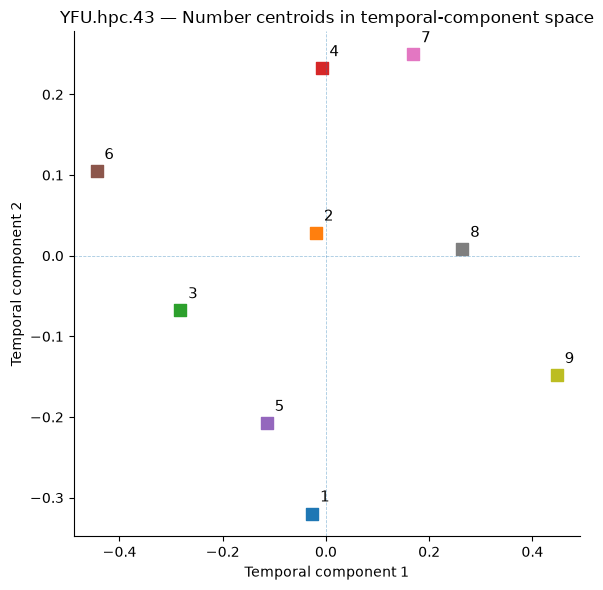

In [104]:
fig, ax = plt.subplots(figsize=(6, 6))

for number in range(1, 10):

    x = fig1h_centroids.loc[number, "TC1"]
    y = fig1h_centroids.loc[number, "TC2"]

    ax.scatter(
        x,
        y,
        marker="s",
        s=70
    )

    ax.text(
        x + 0.015,
        y + 0.015,
        str(number),
        fontsize=11
    )

ax.axhline(0, linestyle="--", linewidth=0.6, alpha=0.4)
ax.axvline(0, linestyle="--", linewidth=0.6, alpha=0.4)

ax.set_xlabel("Temporal component 1")
ax.set_ylabel("Temporal component 2")

ax.set_title(
    "YFU.hpc.43 — Number centroids in temporal-component space"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [105]:
import numpy as np

gamma = 0.8

classes = np.unique(y_g)

# -----------------------------------------
# Class means
# -----------------------------------------
class_means = {
    c: X_g[y_g == c].mean(axis=0)
    for c in classes
}

overall_mean = X_g.mean(axis=0)

# -----------------------------------------
# Within-class pooled covariance
# -----------------------------------------
residual_parts = []

for c in classes:
    Xc = X_g[y_g == c]
    residual_parts.append(
        Xc - class_means[c]
    )

R = np.vstack(residual_parts)

N = len(y_g)
K = len(classes)

Sw = (R.T @ R) / (N - K)

# MATLAB-style Gamma regularization
Sw_reg = (
    (1 - gamma) * Sw
    + gamma * np.diag(np.diag(Sw))
)

# -----------------------------------------
# Between-class covariance
# -----------------------------------------
Sb = np.zeros_like(Sw)

for c in classes:

    Xc = X_g[y_g == c]
    n_c = len(Xc)

    diff = (
        class_means[c] - overall_mean
    ).reshape(-1, 1)

    Sb += n_c * (diff @ diff.T)

Sb = Sb / N

In [106]:
from scipy.linalg import eigh

# Solve:
# Sb w = lambda Sw_reg w

eigvals, eigvecs = eigh(
    Sb,
    Sw_reg
)

# Sort from strongest to weakest discriminant
order = np.argsort(eigvals)[::-1]

eigvals = eigvals[order]
eigvecs = eigvecs[:, order]

print("Eigenvalues:")
print(eigvals)

print("\nEigenvector matrix shape:")
print(eigvecs.shape)

Eigenvalues:
[0.05829509 0.03269223 0.02563272 0.02408568 0.01980961 0.00318782]

Eigenvector matrix shape:
(6, 6)


In [115]:
tc1_weights = -eigvecs[:, 0]
tc2_weights = eigvecs[:, 1]

print("TC1 weights:")
print(tc1_weights)

print("\nTC2 weights:")
print(tc2_weights)

TC1 weights:
[-0.08294408  0.13419694  0.23284664  0.48375056 -0.48285239  0.70120597]

TC2 weights:
[ 0.02236073  0.93765572 -0.01441052 -0.27702228  0.28958001  0.23259512]


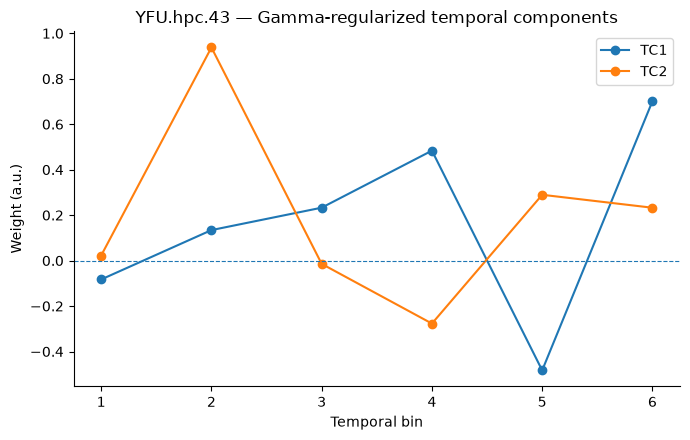

In [118]:
fig1g_corrected = pd.DataFrame({
    "bin": np.arange(1, 7),
    "time_ms": bin_centers_ms,
    "TC1": tc1_weights,
    "TC2": tc2_weights
})

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(
    fig1g_corrected["bin"],
    fig1g_corrected["TC1"],
    marker="o",
    label="TC1"
)

ax.plot(
    fig1g_corrected["bin"],
    fig1g_corrected["TC2"],
    marker="o",
    label="TC2"
)

ax.axhline(
    0,
    linestyle="--",
    linewidth=0.8
)

ax.set_xticks(range(1, 7))

ax.set_xlabel("Temporal bin")
ax.set_ylabel("Weight (a.u.)")

ax.set_title(
    "YFU.hpc.43 — Gamma-regularized temporal components"
)

ax.legend()

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [119]:
W = eigvecs[:, :2]

X_centered = X_g - overall_mean

X_tc = X_centered @ W

print("Projected shape:", X_tc.shape)

Projected shape: (494, 2)


In [120]:
fig1h_projection_corrected = pd.DataFrame({
    "trial_index": fig1g_meta["trial_index"],
    "operand": fig1g_meta["operand"],
    "number": y_g,
    "TC1": X_tc[:, 0],
    "TC2": X_tc[:, 1]
})

In [122]:
fig1h_centroids_corrected = (
    fig1h_projection_corrected
    .groupby("number")[["TC1", "TC2"]]
    .mean()
)

fig1h_centroids_corrected

,TC1,TC2
number,,
1,-0.031048,0.269309
2,-0.018288,-0.000848
3,-0.270782,-0.010246
4,0.005241,-0.217955
5,-0.129508,0.253651
6,-0.446879,-0.070391
7,0.166189,-0.259221
8,0.268264,-0.022739
9,0.441159,0.175225


In [123]:
fig1g_corrected.to_csv(
    tables_dir /
    "figure1G_YFU_hpc43_gamma08_components.csv",
    index=False
)

fig1h_projection_corrected.to_csv(
    tables_dir /
    "figure1H_YFU_hpc43_gamma08_projection.csv",
    index=False
)

fig1h_centroids_corrected.to_csv(
    tables_dir /
    "figure1H_YFU_hpc43_gamma08_centroids.csv"
)

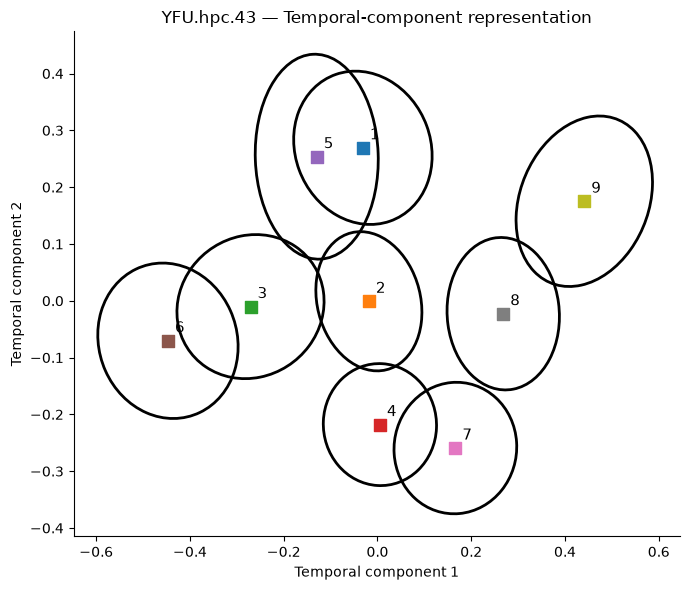

In [127]:
from matplotlib.patches import Ellipse
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 6))

for number in range(1, 10):

    # All projected presentations for this number
    pts = fig1h_projection_corrected[
        fig1h_projection_corrected["number"] == number
    ][["TC1", "TC2"]].to_numpy()

    # Centroid
    mean = pts.mean(axis=0)

    # Number of presentations
    n = len(pts)

    # Trial covariance
    cov = np.cov(pts, rowvar=False)

    # Paper caption:
    # covariance normalized by sqrt(trial count)
    cov_mean = cov / n

    # Eigen-decomposition gives ellipse axes/orientation
    vals, vecs = np.linalg.eigh(cov_mean)

    order = vals.argsort()[::-1]
    vals = vals[order]
    vecs = vecs[:, order]

    angle = np.degrees(
        np.arctan2(vecs[1, 0], vecs[0, 0])
    )

    # 2 SD-style ellipse diameter
    width, height = 2 * np.sqrt(vals)

    # Plot ellipse
    ellipse = Ellipse(
        xy=mean,
        width=width,
        height=height,
        angle=angle,
        fill=False,
        linewidth=2
    )

    ax.add_patch(ellipse)

    # Plot centroid
    ax.scatter(
        mean[0],
        mean[1],
        marker="s",
        s=70
    )

    # Number label
    ax.text(
        mean[0] + 0.015,
        mean[1] + 0.015,
        str(number),
        fontsize=11
    )

ax.set_xlabel("Temporal component 1")
ax.set_ylabel("Temporal component 2")

ax.set_title(
    "YFU.hpc.43 — Temporal-component representation"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

fig.savefig(
    figures_dir /
    "figure1H_YFU_hpc43_temporal_components.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#  LDA - supervised dimensionality-reduction/classification method.

LDA finds a lower-dimensional space specifically chosen to maximize class separation (LDA is a special PCA, converting high dimension classifier  to low dimension discrimant representator) ...Her converted six dimension clasiification to two dimension  using projection , , then  z =  ( x= TC1, y =TC2 ) , given 6 dim point , convert them to two dim point and do classification on this new plot .using centrod, covariance and stuff

# Sign of LDA/temporal components is arbitrary.
# Axis signs are flipped only to match the orientation
# of the published Figure 1H for visual comparison.

---

lDA 1 is the weight and TC 1 is the projection w^T . x

In [126]:
1+1

2

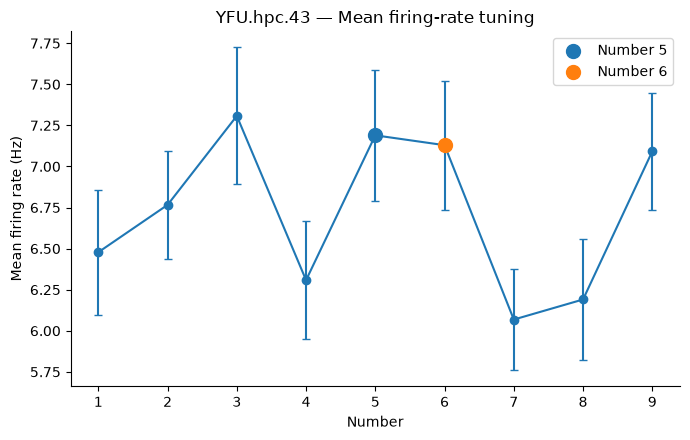

In [128]:
fig, ax = plt.subplots(figsize=(7, 4.5))

# Full tuning curve
ax.errorbar(
    fig1d_summary["number"],
    fig1d_summary["mean_firing_rate_hz"],
    yerr=fig1d_summary["sem_firing_rate_hz"],
    marker="o",
    capsize=3,
    linewidth=1.5
)

# Highlight numbers 5 and 6
for number in [5, 6]:

    row = fig1d_summary[
        fig1d_summary["number"] == number
    ].iloc[0]

    ax.scatter(
        row["number"],
        row["mean_firing_rate_hz"],
        s=100,
        zorder=5,
        label=f"Number {number}"
    )

ax.set_xticks(range(1, 10))

ax.set_xlabel("Number")
ax.set_ylabel("Mean firing rate (Hz)")

ax.set_title(
    "YFU.hpc.43 — Mean firing-rate tuning"
)

ax.legend()

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

fig.savefig(
    figures_dir /
    "YFU_hpc43_firing_rate_tuning_highlight_5_6.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [129]:
fig1d_summary[
    fig1d_summary["number"].isin([5, 6])
]

,number,mean_firing_rate_hz,sem_firing_rate_hz,n_presentations
4,5,7.189542,0.400137,51
5,6,7.129630,0.392605,48


In [130]:
from scipy.ndimage import gaussian_filter1d

sigma_ms = 150

plot_start_ms = 0
plot_end_ms = 1000

# Extra data prevents edge artifacts during smoothing
padding_ms = 450

temporal_56_rows = []

presentations_56 = fig1d_presentations[
    fig1d_presentations["number"].isin([5, 6])
]

for presentation_id, row in presentations_56.iterrows():

    onset = row["onset_ms"]
    number = int(row["number"])

    start = int(round(
        onset + plot_start_ms - padding_ms
    ))

    end = int(round(
        onset + plot_end_ms + padding_ms
    ))

    spike_train = (
        yfu_spike_matrix[
            42,
            start:end
        ]
        .toarray()
        .ravel()
        .astype(float)
    )

    # Gaussian convolution / smoothing
    smooth_rate = gaussian_filter1d(
        spike_train,
        sigma=sigma_ms,
        mode="constant"
    )

    # spikes/ms -> Hz
    smooth_rate_hz = smooth_rate * 1000

    # Remove the padding after smoothing
    smooth_rate_hz = smooth_rate_hz[
        padding_ms:
        padding_ms + (plot_end_ms - plot_start_ms)
    ]

    for t_ms, rate in enumerate(smooth_rate_hz):

        temporal_56_rows.append({
            "presentation_id": presentation_id,
            "number": number,
            "time_s": t_ms / 1000,
            "firing_rate_hz": rate
        })

temporal_56 = pd.DataFrame(
    temporal_56_rows
)

In [131]:
summary_56 = (
    temporal_56
    .groupby(["number", "time_s"])
    .agg(
        mean_rate_hz=("firing_rate_hz", "mean"),
        sem_rate_hz=("firing_rate_hz", "sem"),
        n_presentations=("firing_rate_hz", "count")
    )
    .reset_index()
)

summary_56.head()

,number,time_s,mean_rate_hz,sem_rate_hz,n_presentations
0,5,0.000,6.284144,0.501924,51
1,5,0.001,6.283479,0.501461,51
2,5,0.002,6.282841,0.500998,51
3,5,0.003,6.282249,0.500537,51
4,5,0.004,6.281668,0.500074,51


In [132]:
summary_56.to_csv(
    tables_dir /
    "YFU_hpc43_numbers_5_6_temporal_response.csv",
    index=False
)

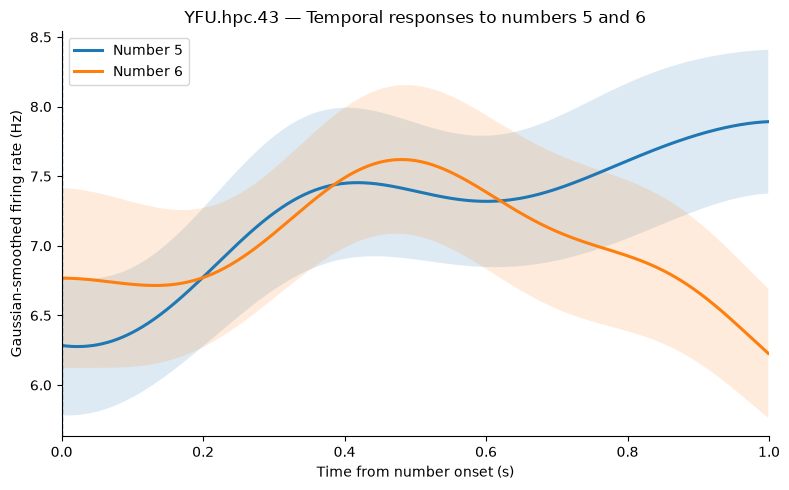

In [133]:
fig, ax = plt.subplots(figsize=(8, 5))

for number in [5, 6]:

    subset = summary_56[
        summary_56["number"] == number
    ]

    x = subset["time_s"].to_numpy()
    mean = subset["mean_rate_hz"].to_numpy()
    sem = subset["sem_rate_hz"].to_numpy()

    line, = ax.plot(
        x,
        mean,
        linewidth=2.2,
        label=f"Number {number}"
    )

    ax.fill_between(
        x,
        mean - sem,
        mean + sem,
        alpha=0.15
    )

ax.axvline(
    0,
    linestyle="--",
    linewidth=1
)

ax.set_xlim(0, 1)

ax.set_xlabel(
    "Time from number onset (s)"
)

ax.set_ylabel(
    "Gaussian-smoothed firing rate (Hz)"
)

ax.set_title(
    "YFU.hpc.43 — Temporal responses to numbers 5 and 6"
)

ax.legend()

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

fig.savefig(
    figures_dir /
    "YFU_hpc43_numbers_5_6_gaussian_temporal_response.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

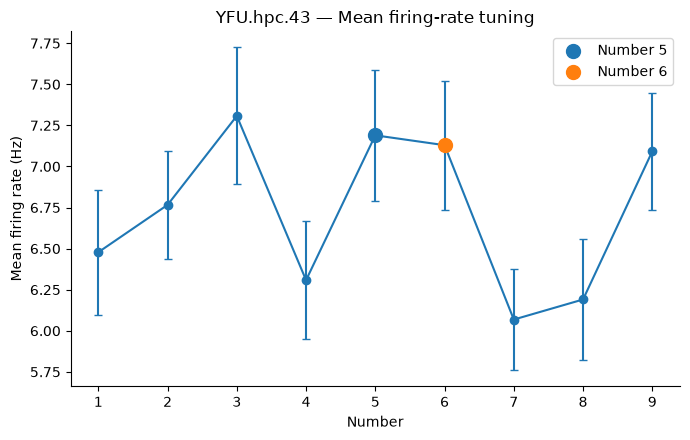

In [134]:
fig, ax = plt.subplots(figsize=(7, 4.5))

# Full tuning curve
ax.errorbar(
    fig1d_summary["number"],
    fig1d_summary["mean_firing_rate_hz"],
    yerr=fig1d_summary["sem_firing_rate_hz"],
    marker="o",
    capsize=3,
    linewidth=1.5
)

# Highlight numbers 5 and 6
for number in [5, 6]:

    row = fig1d_summary[
        fig1d_summary["number"] == number
    ].iloc[0]

    ax.scatter(
        row["number"],
        row["mean_firing_rate_hz"],
        s=100,
        zorder=5,
        label=f"Number {number}"
    )

ax.set_xticks(range(1, 10))

ax.set_xlabel("Number")
ax.set_ylabel("Mean firing rate (Hz)")

ax.set_title(
    "YFU.hpc.43 — Mean firing-rate tuning"
)

ax.legend()

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

fig.savefig(
    figures_dir /
    "YFU_hpc43_firing_rate_tuning_highlight_5_6.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

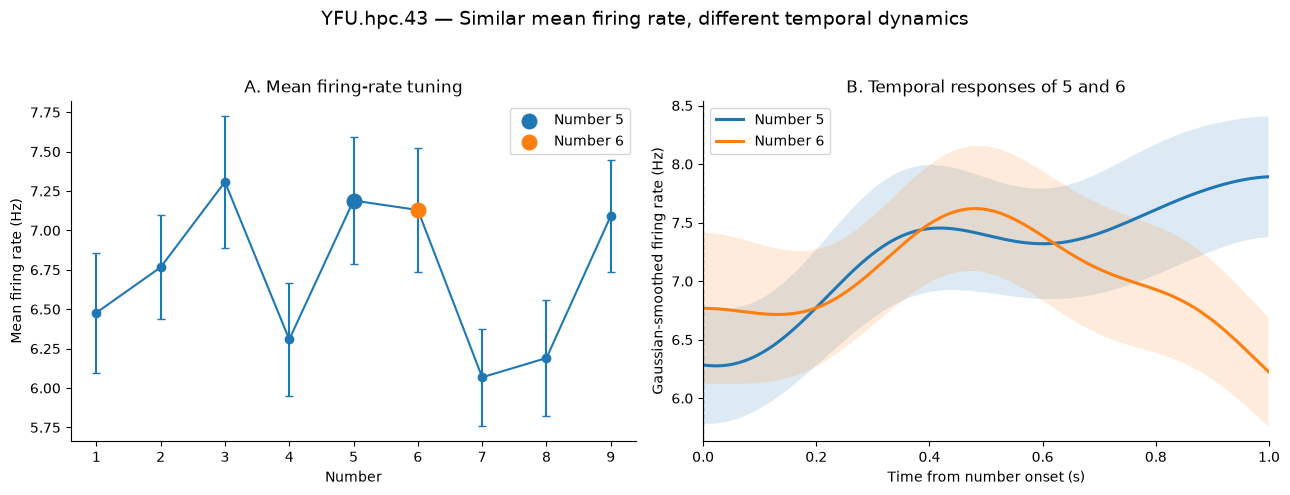

In [135]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(13, 5)
)

# =========================================================
# LEFT PANEL: Mean firing-rate tuning
# =========================================================

ax = axes[0]

ax.errorbar(
    fig1d_summary["number"],
    fig1d_summary["mean_firing_rate_hz"],
    yerr=fig1d_summary["sem_firing_rate_hz"],
    marker="o",
    capsize=3,
    linewidth=1.5
)

# Highlight numbers 5 and 6
for number in [5, 6]:

    row = fig1d_summary[
        fig1d_summary["number"] == number
    ].iloc[0]

    ax.scatter(
        row["number"],
        row["mean_firing_rate_hz"],
        s=110,
        zorder=5,
        label=f"Number {number}"
    )

ax.set_xticks(range(1, 10))

ax.set_xlabel("Number")
ax.set_ylabel("Mean firing rate (Hz)")

ax.set_title(
    "A. Mean firing-rate tuning"
)

ax.legend()

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


# =========================================================
# RIGHT PANEL: Temporal responses for 5 and 6
# =========================================================

ax = axes[1]

for number in [5, 6]:

    subset = summary_56[
        summary_56["number"] == number
    ]

    x = subset["time_s"].to_numpy()
    mean = subset["mean_rate_hz"].to_numpy()
    sem = subset["sem_rate_hz"].to_numpy()

    line, = ax.plot(
        x,
        mean,
        linewidth=2.2,
        label=f"Number {number}"
    )

    ax.fill_between(
        x,
        mean - sem,
        mean + sem,
        alpha=0.15
    )

ax.axvline(
    0,
    linestyle="--",
    linewidth=1
)

ax.set_xlim(0, 1)

ax.set_xlabel(
    "Time from number onset (s)"
)

ax.set_ylabel(
    "Gaussian-smoothed firing rate (Hz)"
)

ax.set_title(
    "B. Temporal responses of 5 and 6"
)

ax.legend()

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


# =========================================================
# MAIN TITLE
# =========================================================

fig.suptitle(
    "YFU.hpc.43 — Similar mean firing rate, different temporal dynamics",
    fontsize=14
)

plt.tight_layout(
    rect=[0, 0, 1, 0.94]
)

# Save
fig.savefig(
    figures_dir /
    "YFU_hpc43_rate_vs_temporal_numbers_5_6.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()